# Data Visualization Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thedannyliu/Diffusion-Policy/blob/final-submission/notebooks/data_visualization.ipynb)

## Running in Google Colab

**Step 1: Clone the repository and install packages**
```python
# Only run this in Google Colab
!git clone https://github.com/thedannyliu/Diffusion-Policy.git
%cd Diffusion-Policy
!pip install zarr matplotlib numpy opencv-python gdown
```

**Step 2: Download the data (~2.5GB)**

The data is hosted on Google Drive. Run this cell to download and extract:

```python
# Download data.zip from Google Drive
!gdown --folder https://drive.google.com/drive/folders/1fy_uOMjU0OhQmbbqVIfamUVsaG92qr6L?usp=sharing

# Or manually download from:
# https://drive.google.com/drive/folders/1fy_uOMjU0OhQmbbqVIfamUVsaG92qr6L?usp=sharing
# This folder contains:
# - Training data (two_cameras_sphere, two_cameras_cube)
# - Evaluation recordings
# - Pre-generated visualizations
```


## Running Locally

If running locally, make sure:
1. Download `data.zip` from [Google Drive](https://drive.google.com/drive/folders/1fy_uOMjU0OhQmbbqVIfamUVsaG92qr6L?usp=sharing) (~2.5GB)
2. Extract to the repository root (should create a `data/` folder)
3. You're in the `notebooks/` directory
4. Install packages: `pip install zarr matplotlib numpy opencv-python`

---

## Setup Instructions

### For Google Colab Users

Run the cells below in order to set up the environment.

In [1]:
# Step 1: Clone repository and install packages (Colab only)
# Uncomment and run if using Google Colab
!git clone https://github.com/thedannyliu/Diffusion-Policy.git
%cd Diffusion-Policy
!pip install zarr matplotlib numpy opencv-python gdown

fatal: destination path 'Diffusion-Policy' already exists and is not an empty directory.
/content/Diffusion-Policy


In [2]:
# Step 2: Download data.zip from Google Drive (~2.5GB)

!gdown --id 1HS3xRutAZzpHWu7o4W0qaKNraEHi4gmA

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1HS3xRutAZzpHWu7o4W0qaKNraEHi4gmA
From (redirected): https://drive.google.com/uc?id=1HS3xRutAZzpHWu7o4W0qaKNraEHi4gmA&confirm=t&uuid=45a4435d-111c-47e0-ba8b-211e5bc308ba
To: /content/Diffusion-Policy/data.zip
100% 2.56G/2.56G [00:31<00:00, 81.6MB/s]


In [3]:
# Step 3: Extract data.zip
# After downloading, extract data.zip to create the data/ folder
# Uncomment and run if using Google Colab
import zipfile
import os

# Look for data.zip in current directory or downloaded folder
zip_paths = ['data.zip', '1fy_uOMjU0OhQmbbqVIfamUVsaG92qr6L/data.zip']
for zip_path in zip_paths:
    if os.path.exists(zip_path):
        print(f"Found {zip_path}, extracting...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Data extracted successfully! data/ folder created.")
        break
else:
    print("data.zip not found. Please download from Google Drive first.")

Found data.zip, extracting...
Data extracted successfully! data/ folder created.


# Data Visualization and Loading Guide

This notebook demonstrates how to load and visualize the datasets used in this project.

## Prerequisites

1. **Data is already available** in the repository:
   ```
   Diffusion-Policy/
   ├── data/
   │   ├── training/
   │   │   ├── two_cameras_cube/       # Real robot cube training demonstrations
   │   │   │   ├── replay_buffer.zarr/
   │   │   │   └── videos/
   │   │   └── two_cameras_sphere/     # Real robot sphere training demonstrations
   │   │       ├── replay_buffer.zarr/
   │   │       └── videos/
   │   └── evaluations/                # Evaluation rollout recordings
   │       ├── eval_two_cameras_sphere/
   │       ├── eval_two_camera_cube/
   │       ├── eval_one_camera_sphere/
   │       ├── eval_one_camera_cube/
   │       └── ... (other evaluation scenarios)
   ```

2. **Install required packages**:
   ```bash
   pip install zarr matplotlib numpy opencv-python
   ```

## Quick Start

Run all cells in this notebook to:
- Load training and evaluation data
- Visualize camera observations from videos
- Plot end-effector trajectories
- Analyze success/failure patterns
- Compare training demonstrations with evaluation rollouts

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Setup paths
repo_root = Path.cwd()  # Corrected: Assumes notebook is in Diffusion-Policy/
data_dir = repo_root / 'data' / 'training'

print(f"Repository root: {repo_root}")
print(f"Data directory: {data_dir}")
print(f"Data directory exists: {data_dir.exists()}")

Repository root: /content/Diffusion-Policy
Data directory: /content/Diffusion-Policy/data/training
Data directory exists: True


In [5]:
# Add scripts directory to path for importing visualization utilities
import sys
scripts_path = repo_root / 'scripts'
print(f"Scripts path: {scripts_path}")
print(f"Scripts path exists: {scripts_path.exists()}")

if str(scripts_path) not in sys.path:
    sys.path.insert(0, str(scripts_path))

print(f"sys.path includes scripts: {str(scripts_path) in sys.path}")

# Import visualization functions from scripts
try:
    from plot_all_episodes_overlay import (
        REFERENCE_POINTS,
        EVAL_FAILURES,
        get_failure_episodes,
        load_all_episodes,
        add_reference_regions_2d,
        plot_2d_overlay  # Main plotting function
    )
    from plot_individual_episodes import (
        load_episode_trajectory,
        extract_video_frames,
        plot_episode_with_frames
    )
    from plot_training_vs_eval import (
        plot_training_vs_eval_comparison
    )
    print("Successfully imported visualization utilities from scripts/")
except ImportError as e:
    print(f"Warning: Could not import some visualization utilities: {e}") # Fixed SyntaxError
    print(f"  Scripts path: {scripts_path}")
    print(f"  Current working directory: {Path.cwd()}")
    print("  Some advanced visualizations may not be available.")
    print("  Note: Make sure you're running from the notebooks/ directory")

Scripts path: /content/Diffusion-Policy/scripts
Scripts path exists: True
sys.path includes scripts: True
Successfully imported visualization utilities from scripts/


---

## 1. Real Robot Training Dataset - Sphere Manipulation

Training demonstrations for pushing a sphere into a goal position.

**Data format:** Zarr array storage  
**File location:** `data/training/two_cameras_sphere/replay_buffer.zarr/`  
**Hardware:** UR10e robot with 2 RealSense D435 cameras

In [6]:
import zarr

# Load sphere training dataset
sphere_training_path = data_dir / 'two_cameras_sphere' / 'replay_buffer.zarr'

if sphere_training_path.exists():
    sphere_data = zarr.open_group(str(sphere_training_path), mode='r')

    print("\n=== Sphere Training Dataset Structure ===")
    print(f"Available keys: {list(sphere_data.keys())}")
    print(f"\nData arrays:")
    for key in sphere_data['data'].keys():
        print(f"  - {key}: shape={sphere_data['data'][key].shape}, dtype={sphere_data['data'][key].dtype}")

    print(f"\nMetadata:")
    episode_ends = sphere_data['meta']['episode_ends'][:]
    print(f"  - Number of episodes: {len(episode_ends)}")
    print(f"  - Total timesteps: {episode_ends[-1]}")
    print(f"  - Average episode length: {episode_ends[-1] / len(episode_ends):.1f} steps")
else:
    print(f"Sphere training data not found at {sphere_training_path}")


=== Sphere Training Dataset Structure ===
Available keys: ['data', 'meta']

Data arrays:
  - action: shape=(9579, 6), dtype=float64
  - robot_joint: shape=(9579, 6), dtype=float64
  - robot_eef_pose: shape=(9579, 6), dtype=float64
  - stage: shape=(9579,), dtype=int64
  - robot_eef_pose_vel: shape=(9579, 6), dtype=float64
  - robot_joint_vel: shape=(9579, 6), dtype=float64
  - timestamp: shape=(9579,), dtype=float64

Metadata:
  - Number of episodes: 100
  - Total timesteps: 9579
  - Average episode length: 95.8 steps


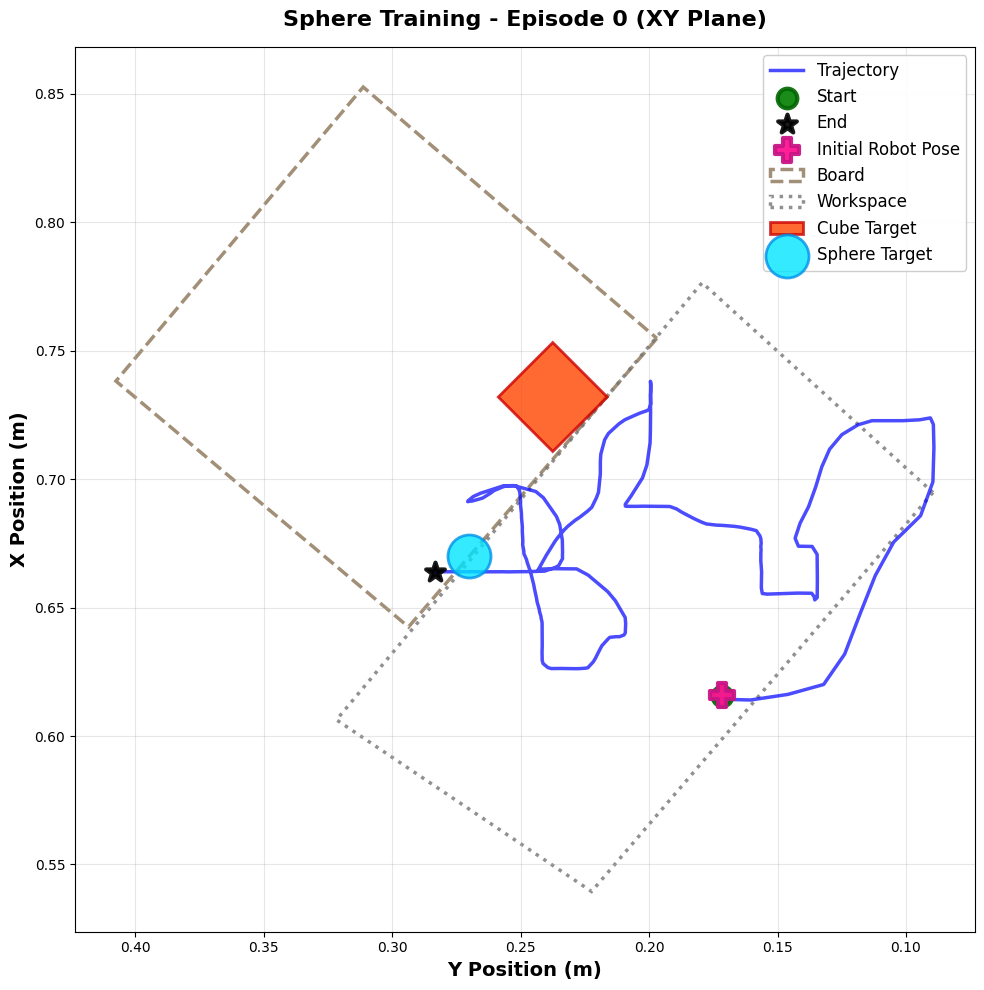


Visualized episode 0 (270 timesteps)
   Start: [0.6157, 0.1718, -0.3015]
   End:   [0.6639, 0.2835, -0.3015]


In [7]:
# Visualize sample sphere training episode with workspace context
if sphere_training_path.exists():
    # Get first episode data
    episode_idx = 0
    start_idx = 0 if episode_idx == 0 else episode_ends[episode_idx - 1]
    end_idx = episode_ends[episode_idx]

    # Extract episode trajectory (end-effector pose)
    episode_trajectory = sphere_data['data']['robot_eef_pose'][start_idx:end_idx]

    # Plot trajectory in XY plane with reference regions
    fig, ax = plt.subplots(figsize=(14, 10))

    # Plot trajectory (swap x/y for visualization convention)
    x_data, y_data = episode_trajectory[:, 1], episode_trajectory[:, 0]
    ax.plot(x_data, y_data, 'b-', linewidth=2.5, alpha=0.7, label='Trajectory')

    # Mark start and end points
    ax.scatter(x_data[0], y_data[0], c='green', s=200, marker='o',
               alpha=0.9, edgecolors='darkgreen', linewidths=3, zorder=5, label='Start')
    ax.scatter(x_data[-1], y_data[-1], c='black', s=200, marker='*',
               alpha=0.9, edgecolors='black', linewidths=3, zorder=5, label='End')

    # Add initial robot pose marker
    tcp_init = REFERENCE_POINTS["tcp_at_j_init"]
    ax.scatter(tcp_init[1], tcp_init[0], c='#FF1493', s=300, marker='P',
              alpha=0.95, edgecolors='#C71585', linewidths=3, zorder=6,
              label='Initial Robot Pose')

    # Add reference regions using imported function
    try:
        add_reference_regions_2d(ax, 'xy', 'sphere')
    except Exception as e:
        print(f"Note: Could not add reference regions: {e}")

    # Labels and formatting
    ax.set_xlabel('Y Position (m)', fontsize=14, fontweight='bold')
    ax.set_ylabel('X Position (m)', fontsize=14, fontweight='bold')
    ax.set_title(f'Sphere Training - Episode {episode_idx} (XY Plane)', fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    ax.invert_xaxis()
    ax.legend(loc='best', fontsize=12, framealpha=0.95)

    plt.tight_layout()
    plt.show()

    print(f"\nVisualized episode {episode_idx} ({len(episode_trajectory)} timesteps)")
    print(f"   Start: [{episode_trajectory[0, 0]:.4f}, {episode_trajectory[0, 1]:.4f}, {episode_trajectory[0, 2]:.4f}]")
    print(f"   End:   [{episode_trajectory[-1, 0]:.4f}, {episode_trajectory[-1, 1]:.4f}, {episode_trajectory[-1, 2]:.4f}]")

---

## 2. Real Robot Training Dataset - Cube Manipulation

Training demonstrations for pushing a cube into a goal slot.

**Data format:** Zarr array storage  
**File location:** `data/training/two_cameras_cube/replay_buffer.zarr/`  
**Hardware:** UR10e robot with 2 RealSense D435 cameras

In [8]:
# Load cube training dataset
cube_training_path = data_dir / 'two_cameras_cube' / 'replay_buffer.zarr'

if cube_training_path.exists():
    cube_data = zarr.open_group(str(cube_training_path), mode='r')

    print("\n=== Cube Training Dataset Structure ===")
    print(f"Available keys: {list(cube_data.keys())}")
    print(f"\nData arrays:")
    for key in cube_data['data'].keys():
        print(f"  - {key}: shape={cube_data['data'][key].shape}, dtype={cube_data['data'][key].dtype}")

    print(f"\nMetadata:")
    cube_episode_ends = cube_data['meta']['episode_ends'][:]
    print(f"  - Number of episodes: {len(cube_episode_ends)}")
    print(f"  - Total timesteps: {cube_episode_ends[-1]}")
    print(f"  - Average episode length: {cube_episode_ends[-1] / len(cube_episode_ends):.1f} steps")
else:
    print(f"Cube training data not found at {cube_training_path}")


=== Cube Training Dataset Structure ===
Available keys: ['data', 'meta']

Data arrays:
  - action: shape=(17667, 6), dtype=float64
  - robot_joint: shape=(17667, 6), dtype=float64
  - robot_eef_pose: shape=(17667, 6), dtype=float64
  - robot_eef_pose_vel: shape=(17667, 6), dtype=float64
  - stage: shape=(17667,), dtype=int64
  - timestamp: shape=(17667,), dtype=float64
  - robot_joint_vel: shape=(17667, 6), dtype=float64

Metadata:
  - Number of episodes: 100
  - Total timesteps: 17667
  - Average episode length: 176.7 steps


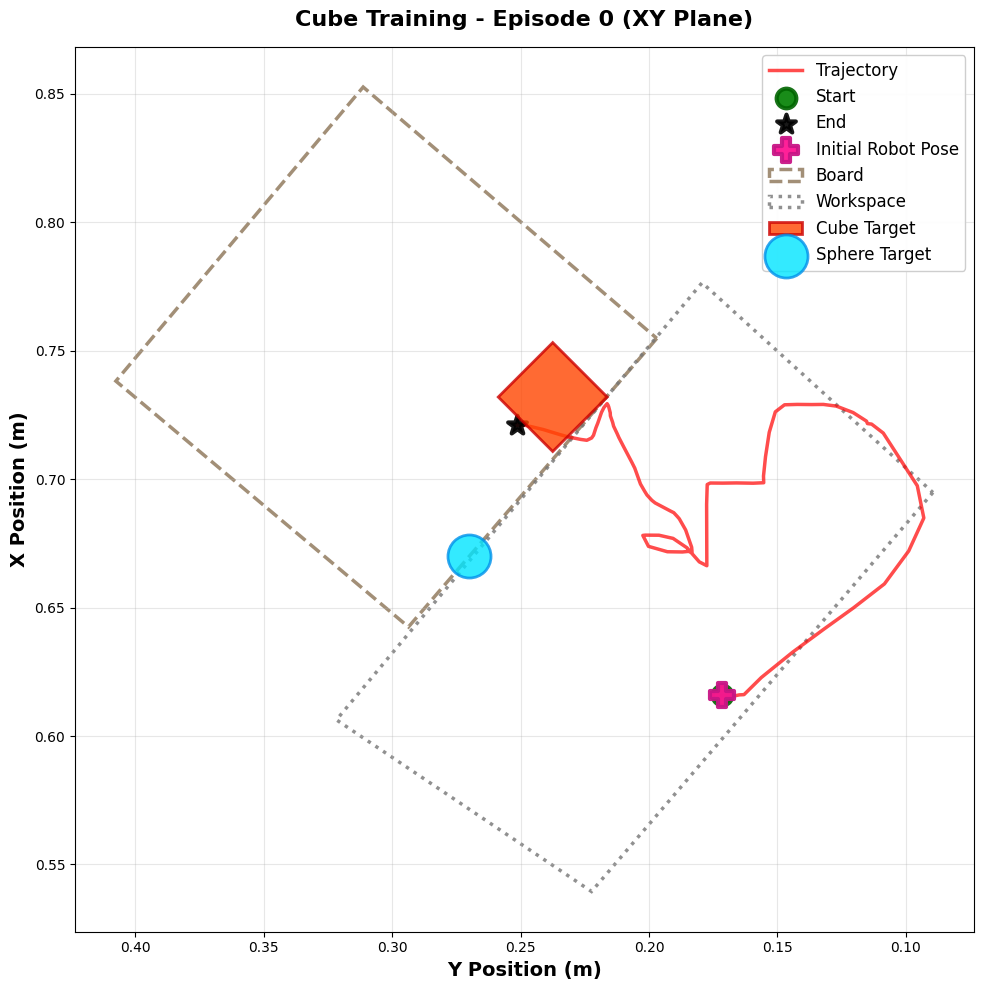


Visualized cube episode 0 (160 timesteps)
   Start: [0.6158, 0.1718, -0.3014]
   End:   [0.7211, 0.2516, -0.3014]


In [9]:
# Visualize sample cube training episode with workspace context
if cube_training_path.exists():
    # Get first episode data
    episode_idx = 0
    start_idx = 0 if episode_idx == 0 else cube_episode_ends[episode_idx - 1]
    end_idx = cube_episode_ends[episode_idx]

    # Extract episode trajectory
    cube_trajectory = cube_data['data']['robot_eef_pose'][start_idx:end_idx]

    # Plot trajectory in XY plane with reference regions
    fig, ax = plt.subplots(figsize=(14, 10))

    # Plot trajectory (swap x/y for visualization convention)
    x_data, y_data = cube_trajectory[:, 1], cube_trajectory[:, 0]
    ax.plot(x_data, y_data, 'r-', linewidth=2.5, alpha=0.7, label='Trajectory')

    # Mark start and end points
    ax.scatter(x_data[0], y_data[0], c='green', s=200, marker='o',
               alpha=0.9, edgecolors='darkgreen', linewidths=3, zorder=5, label='Start')
    ax.scatter(x_data[-1], y_data[-1], c='black', s=200, marker='*',
               alpha=0.9, edgecolors='black', linewidths=3, zorder=5, label='End')

    # Add initial robot pose marker
    tcp_init = REFERENCE_POINTS["tcp_at_j_init"]
    ax.scatter(tcp_init[1], tcp_init[0], c='#FF1493', s=300, marker='P',
              alpha=0.95, edgecolors='#C71585', linewidths=3, zorder=6,
              label='Initial Robot Pose')

    # Add reference regions using imported function
    try:
        add_reference_regions_2d(ax, 'xy', 'cube')
    except Exception as e:
        print(f"Note: Could not add reference regions: {e}")

    # Labels and formatting
    ax.set_xlabel('Y Position (m)', fontsize=14, fontweight='bold')
    ax.set_ylabel('X Position (m)', fontsize=14, fontweight='bold')
    ax.set_title(f'Cube Training - Episode {episode_idx} (XY Plane)', fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    ax.invert_xaxis()
    ax.legend(loc='best', fontsize=12, framealpha=0.95)

    plt.tight_layout()
    plt.show()

    print(f"\nVisualized cube episode {episode_idx} ({len(cube_trajectory)} timesteps)")
    print(f"   Start: [{cube_trajectory[0, 0]:.4f}, {cube_trajectory[0, 1]:.4f}, {cube_trajectory[0, 2]:.4f}]")
    print(f"   End:   [{cube_trajectory[-1, 0]:.4f}, {cube_trajectory[-1, 1]:.4f}, {cube_trajectory[-1, 2]:.4f}]")

---

## 4. Trajectory Plots from Evaluations

Pre-generated trajectory plots are available in the `Trajectory_Plots/` folder.

Processing 9 evaluation folders

eval_one_camera_cube: 32 episodes, 2 failures


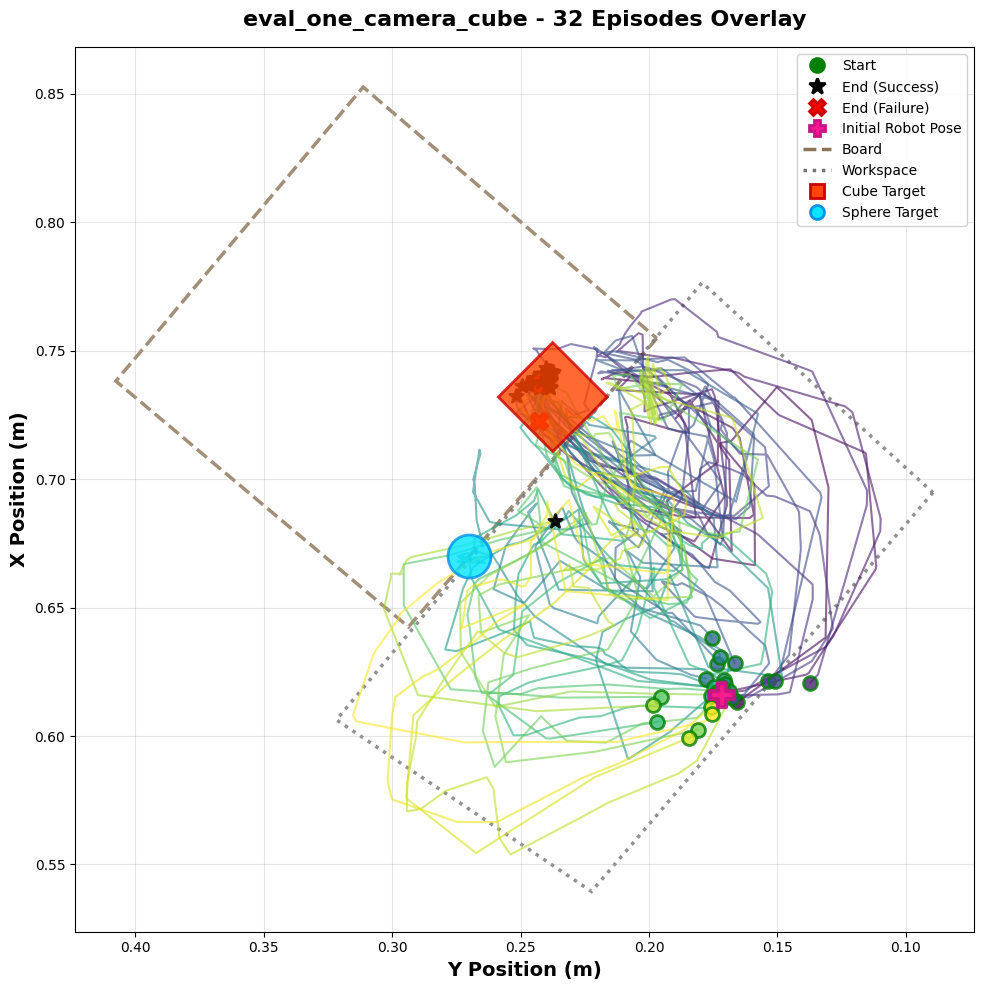

eval_one_camera_sphere: 32 episodes, 14 failures


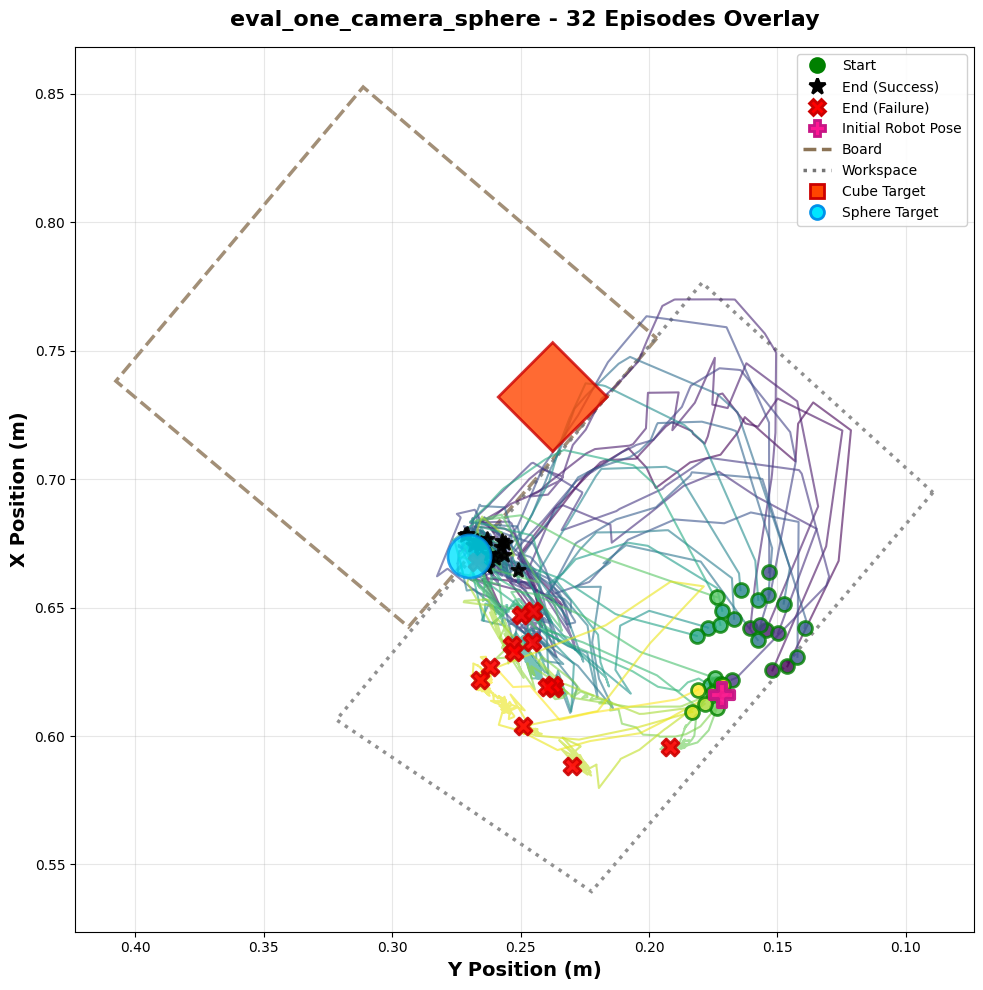

eval_two_camera_cube: 52 episodes, 7 failures


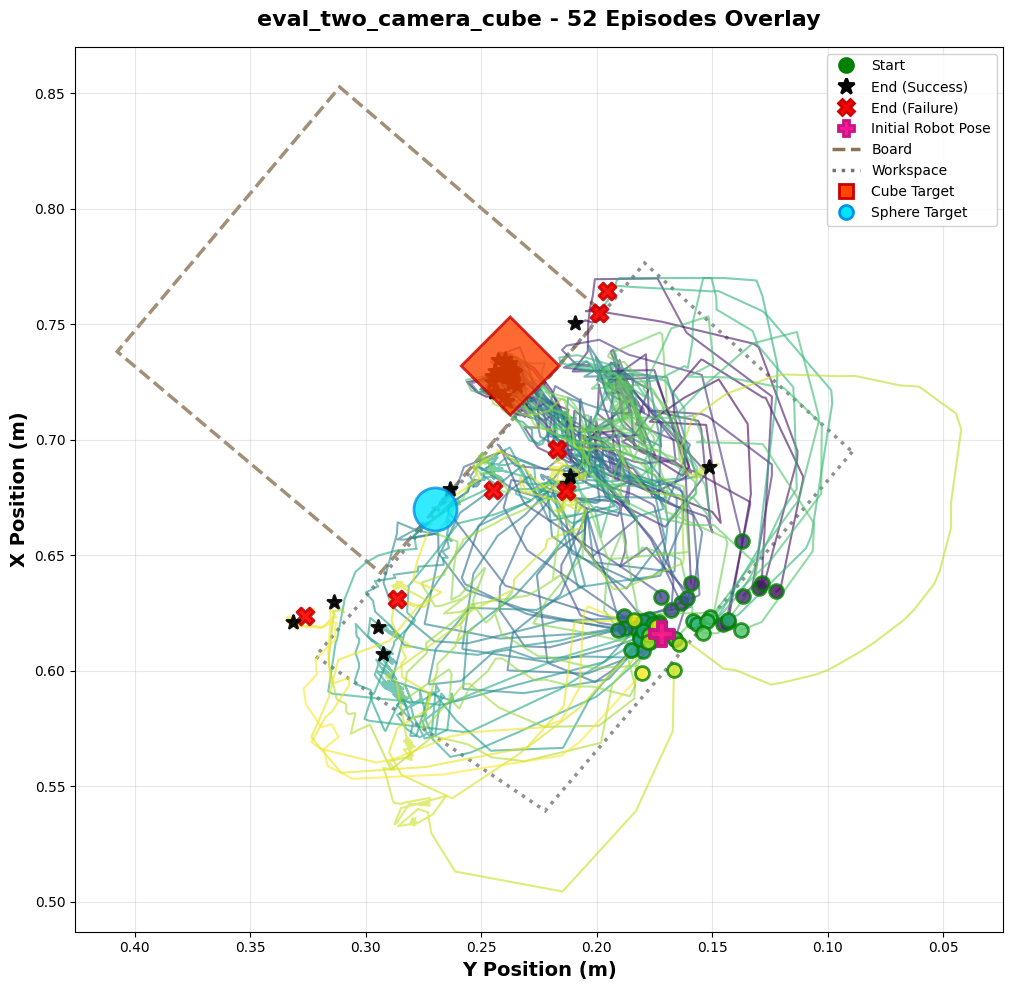

eval_two_camera_cube_with_all_disturbances: 10 episodes, 3 failures


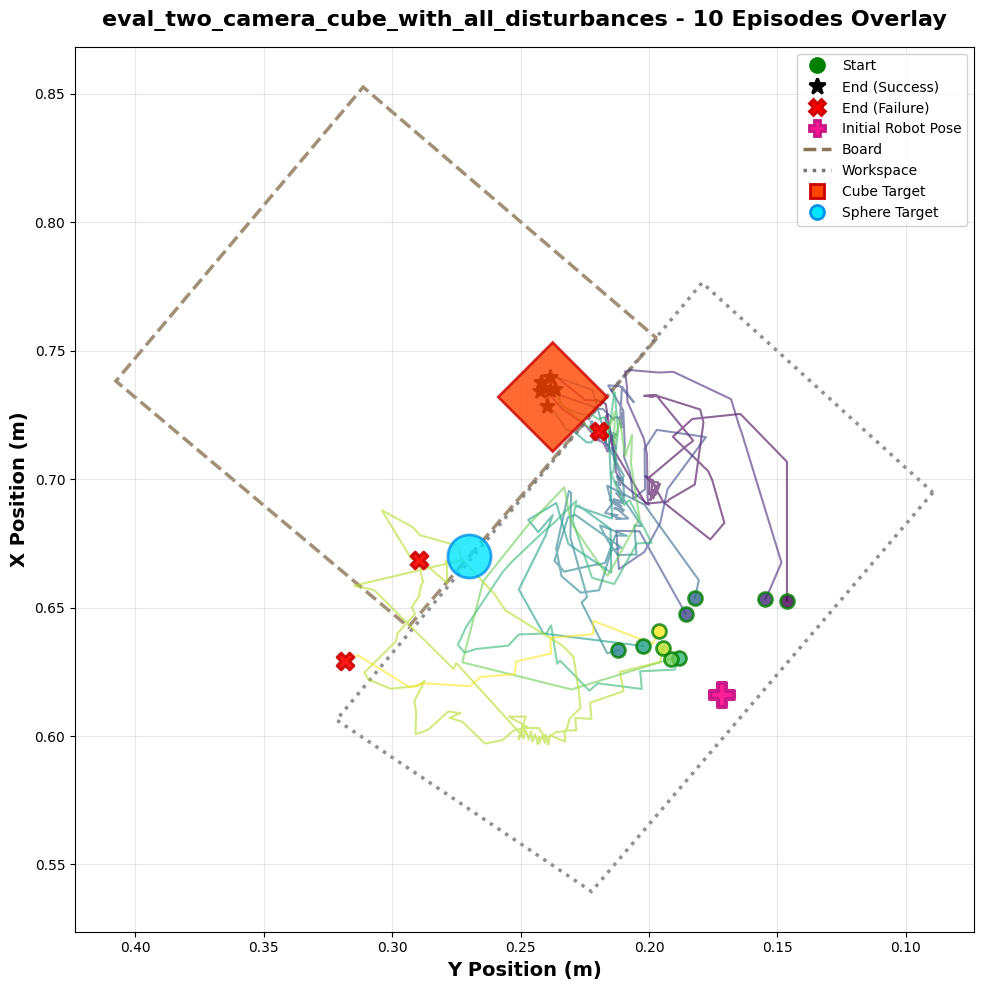

eval_two_cameras_cube_up_to_31: 32 episodes, 7 failures


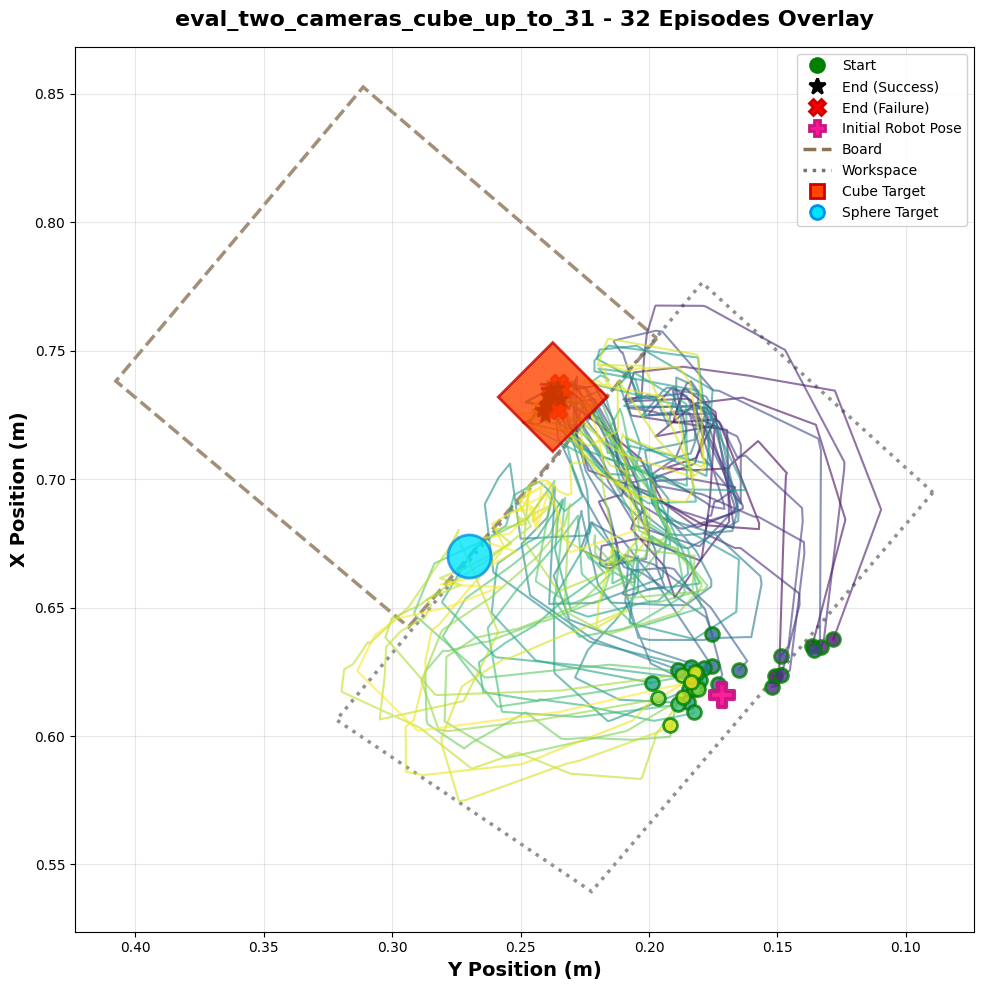

eval_two_cameras_cubes_with_no_glvoes_and_white_objects_as_disturbances: 10 episodes, 1 failures


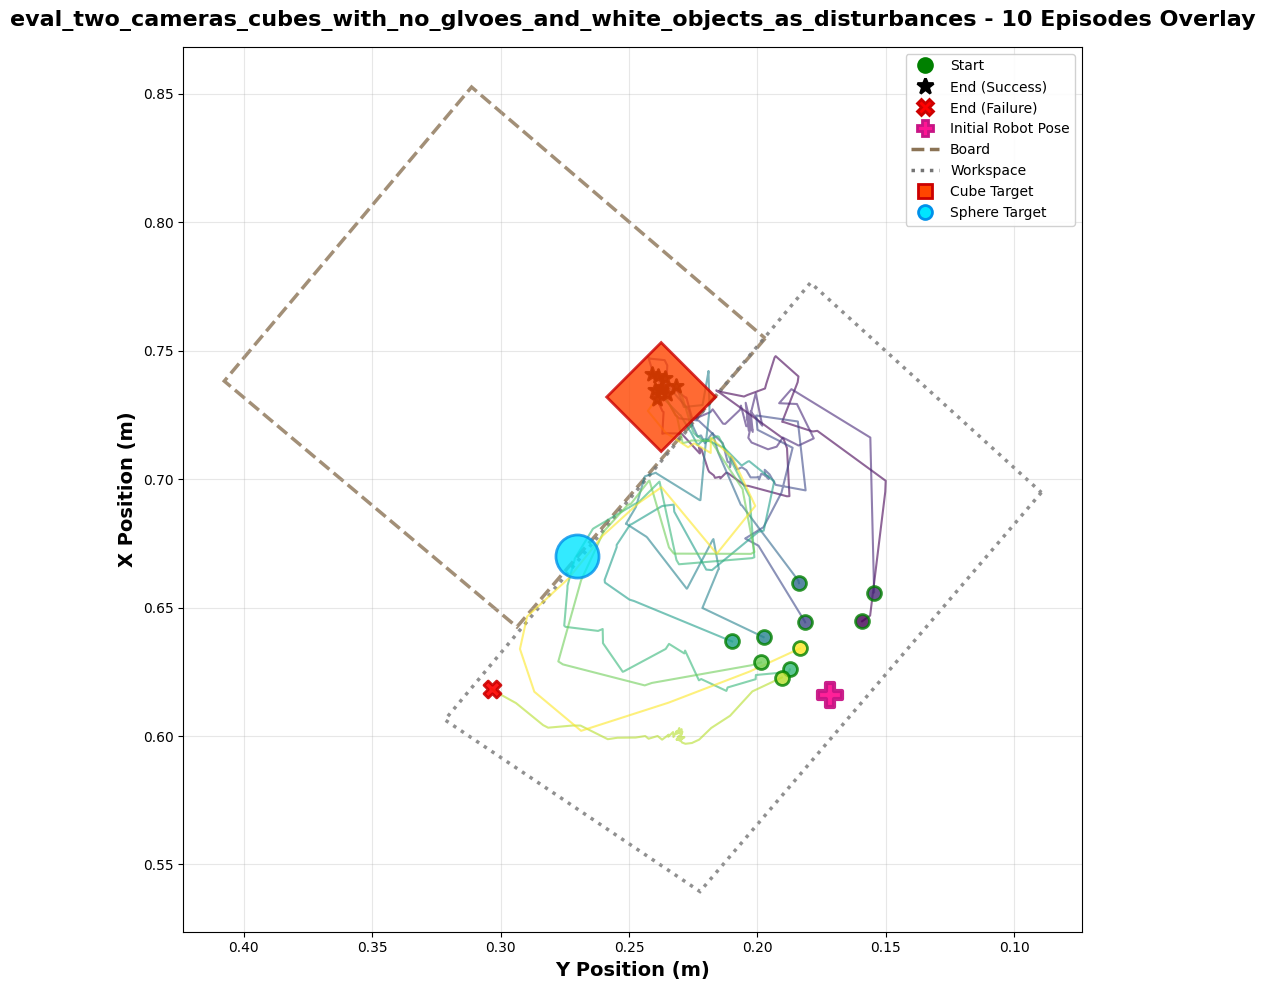

eval_two_cameras_cubes_with_noglvoes: 10 episodes, 0 failures


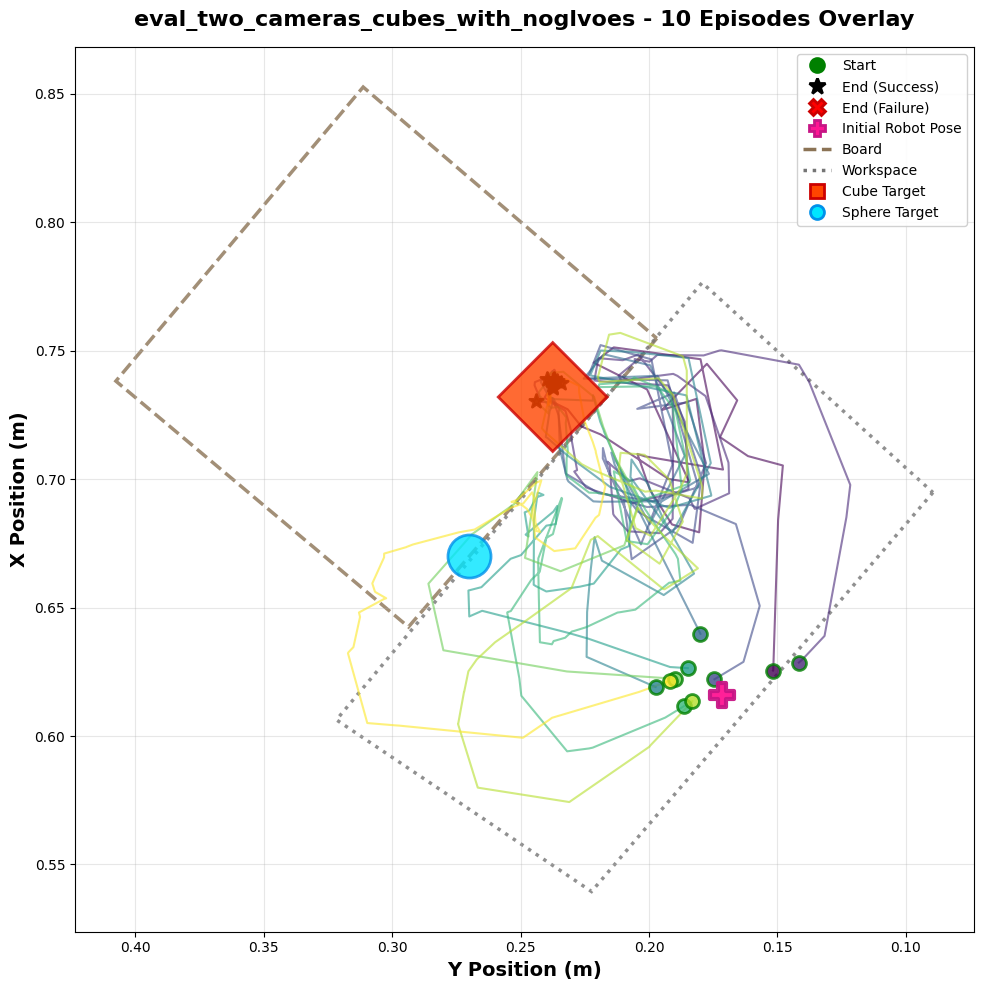

eval_two_cameras_sphere: 52 episodes, 3 failures


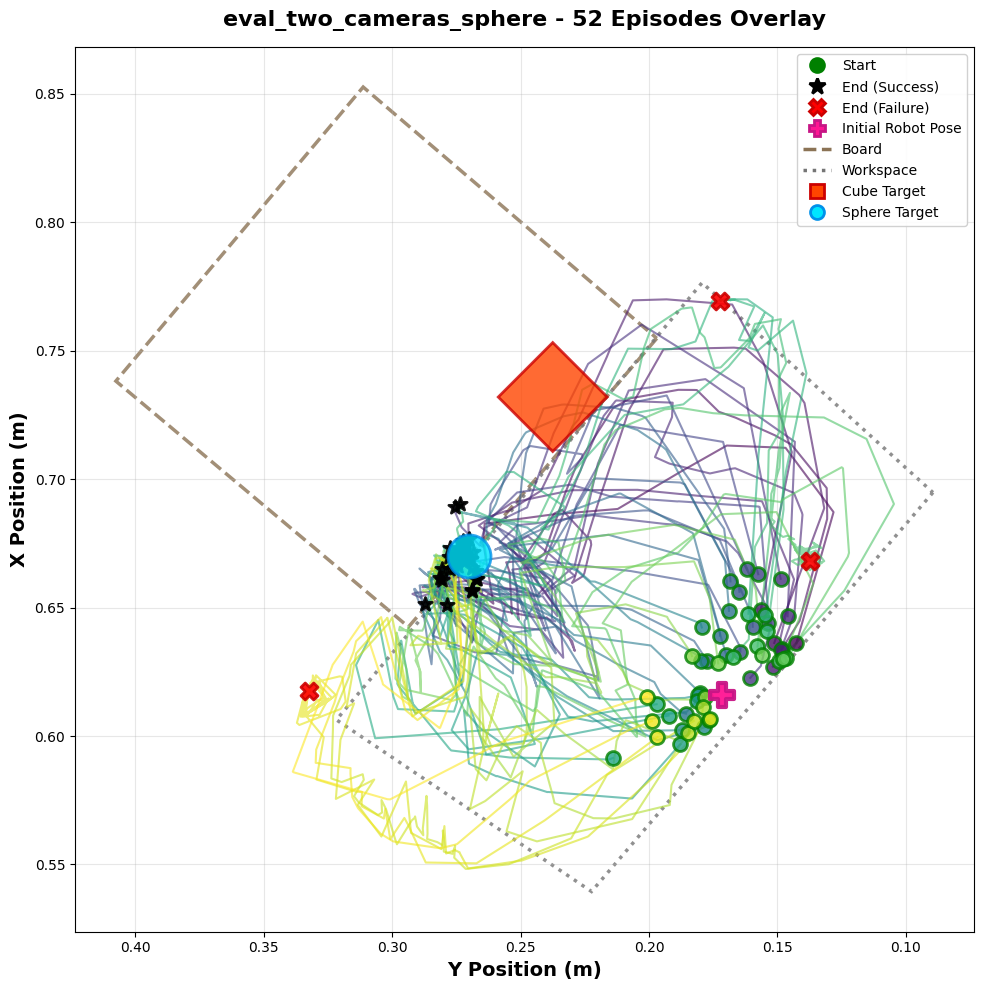

eval_two_cameras_sphere_to_cube: 16 episodes, 0 failures


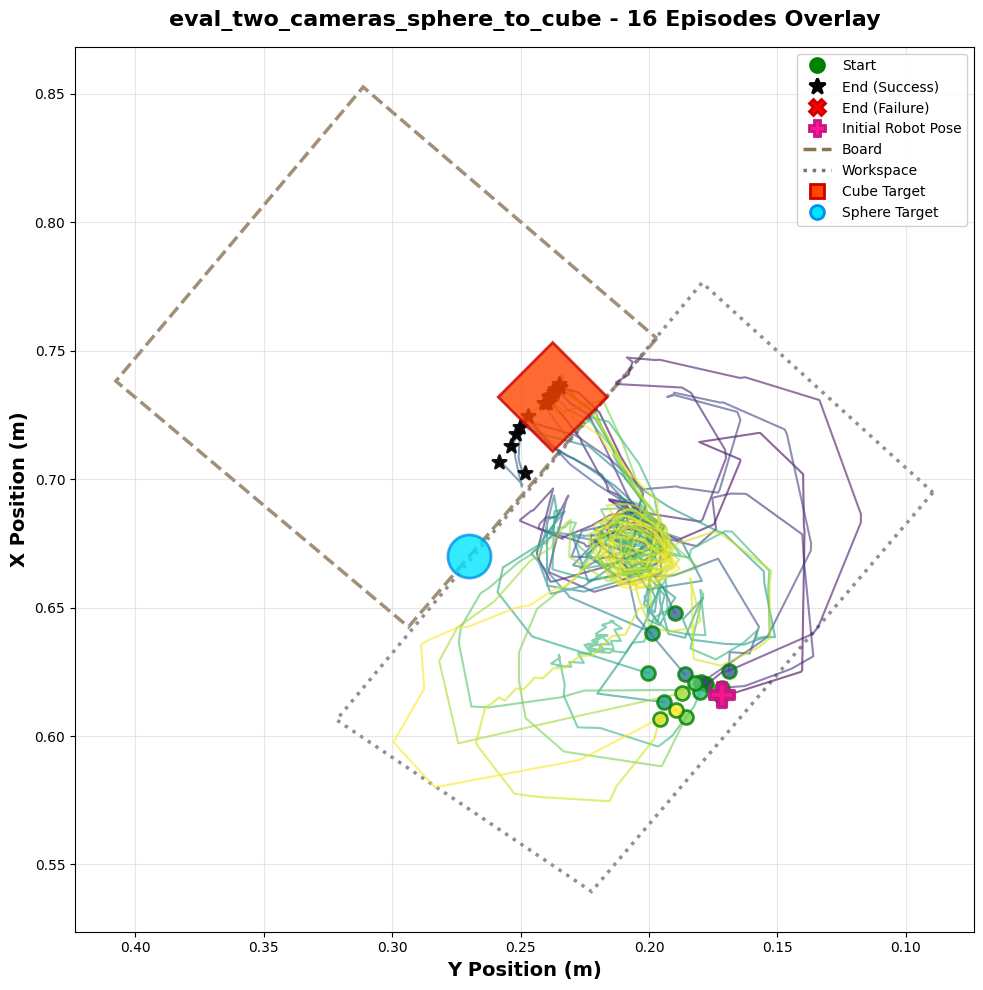

In [10]:
# Generate overlay plots for evaluations
eval_data_dir = repo_root / 'data' / 'evaluations'

if eval_data_dir.exists():
    eval_folders = sorted([d for d in eval_data_dir.iterdir() if d.is_dir() and d.name.startswith('eval_')])

    print(f"Processing {len(eval_folders)} evaluation folders\n")

    for eval_folder in eval_folders:
        buffer_path = eval_folder / 'replay_buffer.zarr'

        if not buffer_path.exists():
            continue

        eval_name = eval_folder.name

        try:
            # Load all episodes using script function
            episodes, stats = load_all_episodes(buffer_path)
            failure_episodes = get_failure_episodes(eval_name)

            print(f"{eval_name}: {stats['num_episodes']} episodes, {len(failure_episodes)} failures")

            # Create plot using script function with all features
            fig, ax = plt.subplots(figsize=(14, 10))

            # Get colormap
            colors = plt.cm.viridis(np.linspace(0, 1, len(episodes)))

            # Plot each episode
            for i, (trajectory, color) in enumerate(zip(episodes, colors)):
                x_data, y_data = trajectory[:, 1], trajectory[:, 0]  # Swapped: Y on x-axis, X on y-axis
                ax.plot(x_data, y_data, color=color, linewidth=1.5, alpha=0.6)

                # Mark start points
                ax.scatter(x_data[0], y_data[0], c=[color], s=100, marker='o',
                          alpha=0.8, edgecolors='green', linewidths=2, zorder=5)

                # Different markers for failures vs successes
                if i in failure_episodes:
                    ax.scatter(x_data[-1], y_data[-1], c='#FF0000', s=150, marker='X',
                              alpha=0.9, edgecolors='#CC0000', linewidths=2, zorder=5)
                else:
                    ax.scatter(x_data[-1], y_data[-1], c='black', s=100, marker='*',
                              alpha=0.9, edgecolors='black', linewidths=2, zorder=5)

            # Add initial robot pose marker
            tcp_init = REFERENCE_POINTS["tcp_at_j_init"]
            ax.scatter(tcp_init[1], tcp_init[0], c='#FF1493', s=300, marker='P',
                      alpha=0.95, edgecolors='#C71585', linewidths=3, zorder=6,
                      label='Initial Robot Pose')

            # Add reference regions
            try:
                add_reference_regions_2d(ax, 'xy', eval_name)
            except Exception as e:
                print(f"Note: Could not add reference regions: {e}")

            ax.set_xlabel('Y Position (m)', fontsize=14, fontweight='bold')
            ax.set_ylabel('X Position (m)', fontsize=14, fontweight='bold')
            ax.set_title(f'{eval_name} - {len(episodes)} Episodes Overlay', fontsize=16, fontweight='bold', pad=15)
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal', adjustable='box')
            ax.invert_xaxis()

            # Build comprehensive legend
            from matplotlib.lines import Line2D
            custom_lines = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='g',
                       markersize=10, markeredgecolor='green', markeredgewidth=2,
                       label='Start'),
                Line2D([0], [0], marker='*', color='w', markerfacecolor='black',
                       markersize=12, markeredgecolor='black', markeredgewidth=2,
                       label='End (Success)'),
                Line2D([0], [0], marker='X', color='w', markerfacecolor='#FF0000',
                       markersize=12, markeredgecolor='#CC0000', markeredgewidth=2,
                       label='End (Failure)'),
                Line2D([0], [0], marker='P', color='w', markerfacecolor='#FF1493',
                       markersize=12, markeredgecolor='#C71585', markeredgewidth=2,
                       label='Initial Robot Pose'),
                Line2D([0], [0], color='#8B7355', linewidth=2.5, linestyle='--',
                       label='Board'),
                Line2D([0], [0], color='#757575', linewidth=2.5, linestyle=':',
                       label='Workspace'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF4500',
                       markersize=10, markeredgecolor='#CC0000', markeredgewidth=2,
                       label='Cube Target'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#00E5FF',
                       markersize=10, markeredgecolor='#0091EA', markeredgewidth=2,
                       label='Sphere Target')
            ]
            ax.legend(handles=custom_lines, loc='best', fontsize=10, framealpha=0.9)

            plt.tight_layout()
            plt.show()
            plt.close()

        except Exception as e:
            print(f"Error generating plot for {eval_name}: {e}")

---

## 5. Training vs Evaluation Comparisons

Compare training demonstrations with evaluation rollouts for sphere and cube tasks.


Comparing: two_cameras_sphere vs eval_two_cameras_sphere
Training: 100 episodes
Evaluation: 52 episodes (3 failures)


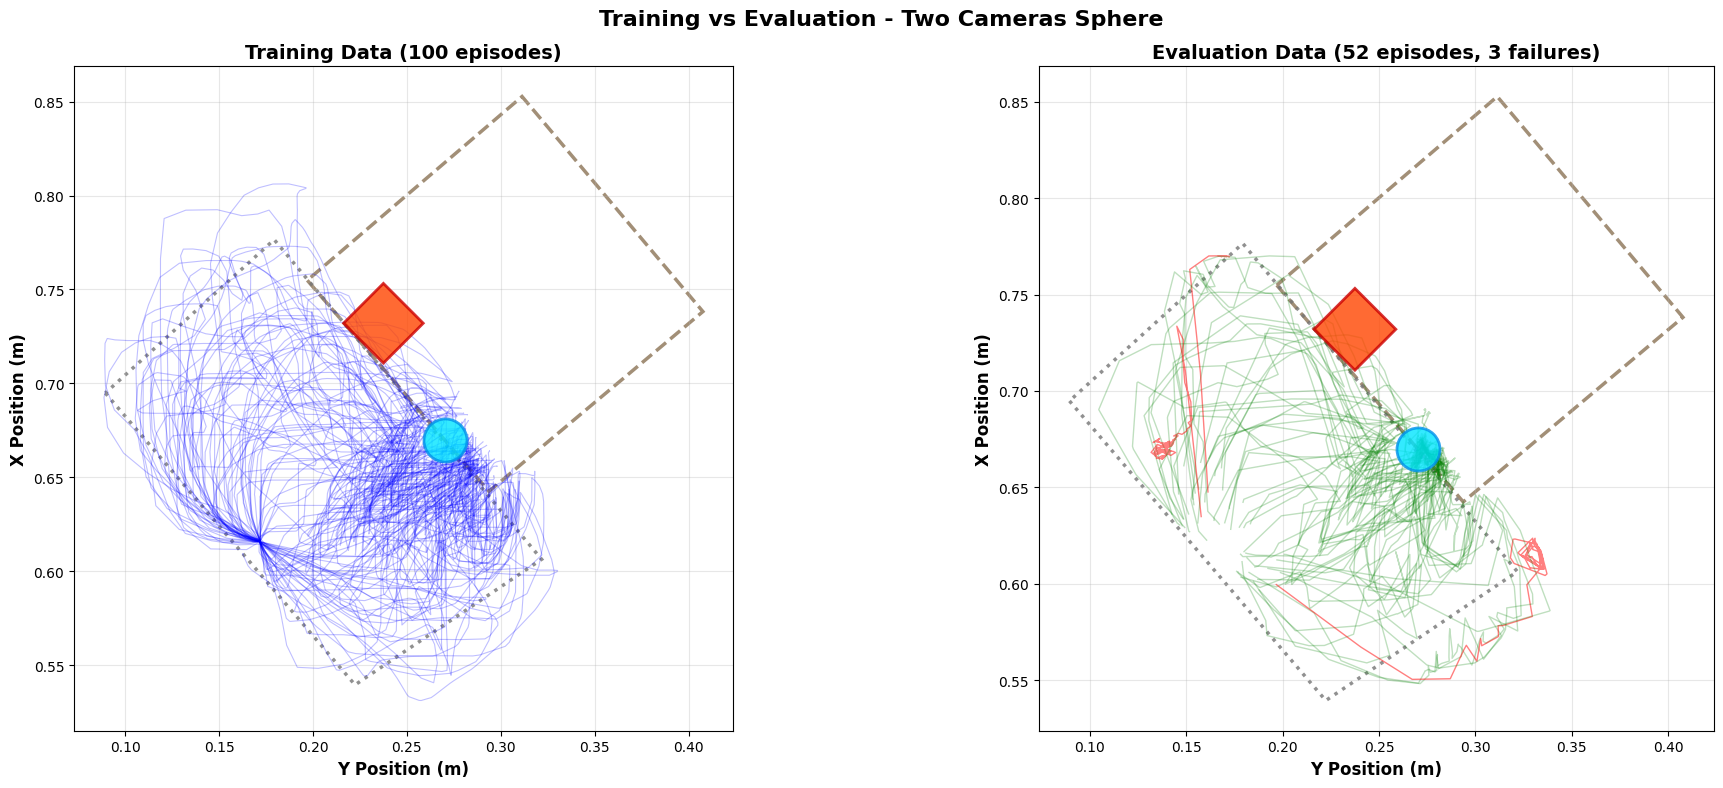


Comparing: two_cameras_cube vs eval_two_camera_cube
Training: 100 episodes
Evaluation: 52 episodes (7 failures)


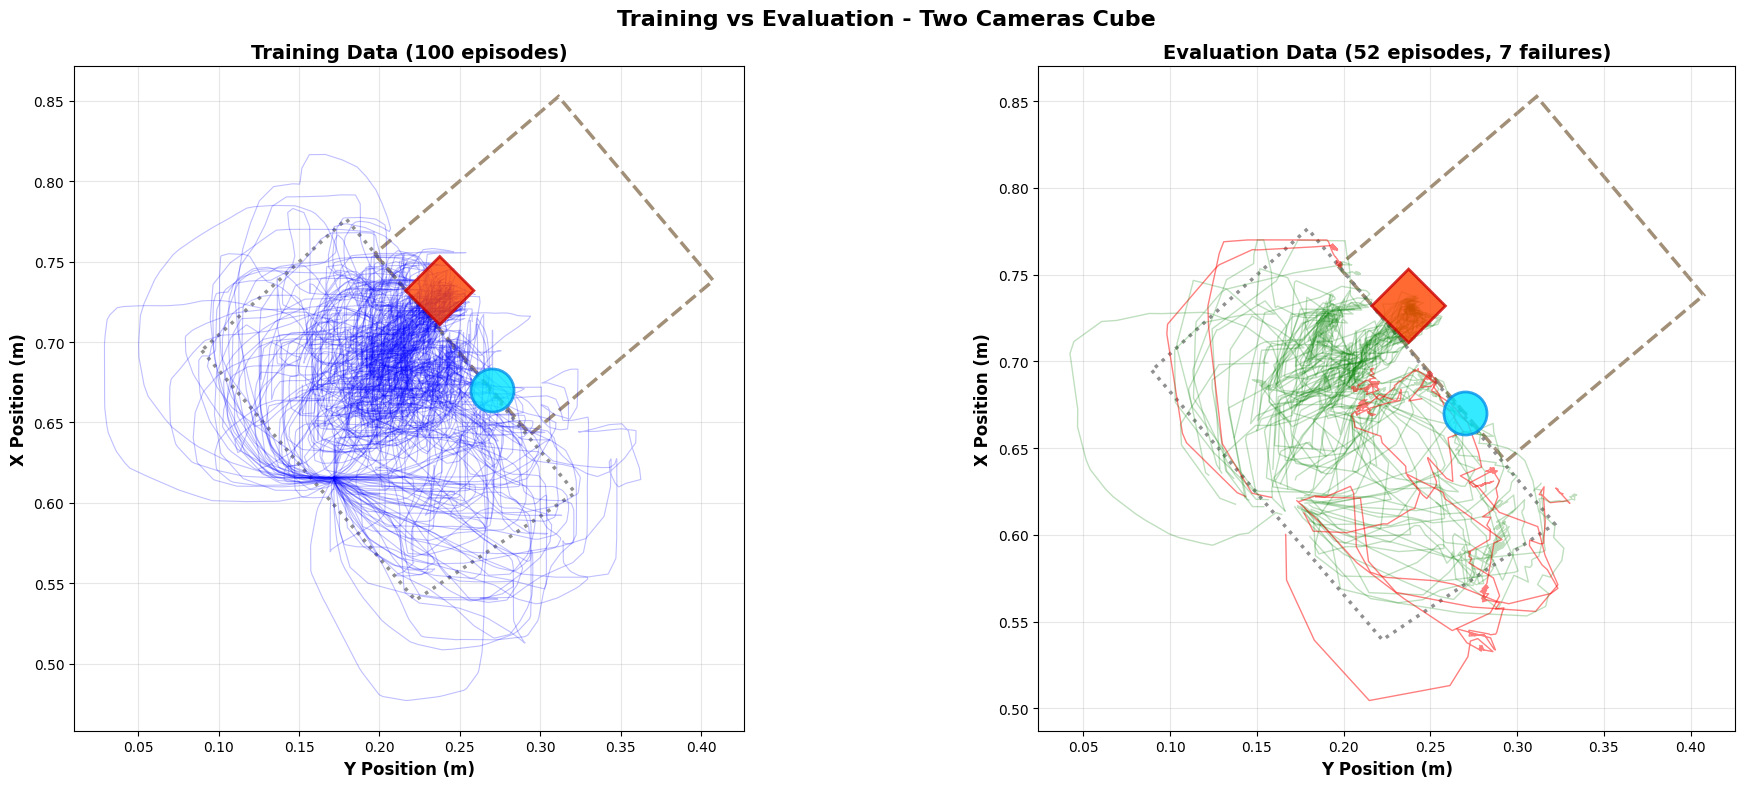

In [11]:
# Generate training vs evaluation comparison plots
training_eval_pairs = [
    ('two_cameras_sphere', 'eval_two_cameras_sphere'),
    ('two_cameras_cube', 'eval_two_camera_cube'),
]

for training_name, comparison_eval_name in training_eval_pairs:
    training_path = data_dir / training_name / 'replay_buffer.zarr'
    eval_path = eval_data_dir / comparison_eval_name / 'replay_buffer.zarr'

    if not (training_path.exists() and eval_path.exists()):
        print(f"Skipping {training_name} - missing data")
        continue

    print(f"\n{'='*60}")
    print(f"Comparing: {training_name} vs {comparison_eval_name}")
    print(f"{'='*60}")

    try:
        # Load data using script function
        training_episodes = load_all_episodes(training_path)[0]
        eval_episodes = load_all_episodes(eval_path)[0]
        comparison_failures = get_failure_episodes(comparison_eval_name)

        print(f"Training: {len(training_episodes)} episodes")
        print(f"Evaluation: {len(eval_episodes)} episodes ({len(comparison_failures)} failures)")

        # Create side-by-side comparison plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

        # Plot training data
        for episode in training_episodes:
            ax1.plot(episode[:, 1], episode[:, 0], 'b-', alpha=0.25, linewidth=0.8)
        try:
            add_reference_regions_2d(ax1)
        except:
            pass
        ax1.set_xlabel('Y Position (m)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('X Position (m)', fontsize=12, fontweight='bold')
        ax1.set_title(f'Training Data ({len(training_episodes)} episodes)', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal', adjustable='box')

        # Plot evaluation data
        for i, episode in enumerate(eval_episodes):
            color = 'red' if i in comparison_failures else 'green'
            alpha = 0.5 if i in comparison_failures else 0.25
            ax2.plot(episode[:, 1], episode[:, 0], color=color, alpha=alpha, linewidth=1.0)
        try:
            add_reference_regions_2d(ax2)
        except:
            pass
        ax2.set_xlabel('Y Position (m)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('X Position (m)', fontsize=12, fontweight='bold')
        ax2.set_title(f'Evaluation Data ({len(eval_episodes)} episodes, {len(comparison_failures)} failures)', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal', adjustable='box')

        plt.suptitle(f'Training vs Evaluation - {training_name.replace("_", " ").title()}', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
        plt.close()

    except Exception as e:
        print(f"Error: {e}")